# Import All Required Models and Libraries

Running all cells will likely take approximately 5 minutes at most.

In [1]:
# Install libaries not included in Colab by default. ONLY run this cell if using Google Colab.

# !pip install catboost

In [2]:
# ONLY run this cell if using Google Colab.

# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# Beginning of imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, auc, roc_curve, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import xgboost as xgb   # pip install xgboost
import lightgbm as lgb  # pip install lightgbm
import catboost as cat  # pip install catboost

# Dataset - 'dataset_phishing.csv' (Has varying feature values)
From https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset/data

## Data Loading and Pre-Processing

In [4]:
# Data is fetched from Google drive. It must be located in this directory for this to work ONLY IF using Google Colab.
# data = pd.read_csv('/content/drive/MyDrive/CP8210-Topics in Data Science/Term Paper/dataset_phishing.csv')

# Data is fetched from the same directory as this file. For simplicity, run this cell with the line above commented out.
data = pd.read_csv('dataset_phishing.csv')

# Display the first 5 rows of the dataset to understand the data.
data.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [5]:
# Use LabelEncoder to transform the 'status' column into a binary representation
encoder = LabelEncoder()
encoded_target = encoder.fit_transform(data['status'])

data['encoded_status'] = encoded_target
data = data.drop(columns=['url', 'status'])
# The 'url' column's values are always unique and therefore are not needed
# 'status' is no longer needed as 'encoded_status' is a binary representation of the two string values in this column

print(encoder.classes_) # 0 = legitimate, 1 = phishing

# Display the first 5 rows again to see the `encoded_status` column. (Scroll all the way to the right to see it.)
data.head()

['legitimate' 'phishing']


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,encoded_status
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,1
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,0
4,55,15,0,2,2,0,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,0


In [6]:
# Split the data into training and testing sets
X = data.drop(columns=['encoded_status'])
y = data['encoded_status']

# Use 30% of the data for testing with random state of 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the training and testing data before classification
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Determining Feature Importance

In [7]:
print("FEATURE IMPORTANCE")
feature_importances = mutual_info_classif(X, y)

# Sort features and importances based on importance values
sorted_indices = feature_importances.argsort()[::-1]
sorted_features = X.columns[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

for feature, importance in zip(sorted_features, sorted_importances):
    print(f"{feature}: {importance:.4f}")

FEATURE IMPORTANCE
google_index: 0.3020
web_traffic: 0.3004
domain_age: 0.2819
ratio_intHyperlinks: 0.2391
ratio_extHyperlinks: 0.2330
nb_hyperlinks: 0.2264
page_rank: 0.2157
safe_anchor: 0.1821
domain_registration_length: 0.1502
links_in_tags: 0.1279
ratio_extRedirection: 0.1277
longest_word_path: 0.1080
ratio_digits_url: 0.1073
nb_www: 0.0996
longest_words_raw: 0.0860
ratio_extErrors: 0.0833
char_repeat: 0.0813
avg_word_path: 0.0809
phish_hints: 0.0806
avg_words_raw: 0.0762
avg_word_host: 0.0750
shortest_word_host: 0.0745
length_url: 0.0721
ratio_intMedia: 0.0697
ratio_extMedia: 0.0639
domain_in_title: 0.0628
nb_dots: 0.0628
ip: 0.0600
length_hostname: 0.0588
ratio_digits_host: 0.0534
length_words_raw: 0.0445
nb_qm: 0.0443
nb_eq: 0.0441
shortest_words_raw: 0.0417
shortest_word_path: 0.0373
nb_hyphens: 0.0371
prefix_suffix: 0.0361
nb_slash: 0.0357
nb_subdomains: 0.0294
tld_in_subdomain: 0.0289
nb_and: 0.0285
longest_word_host: 0.0250
empty_title: 0.0229
domain_with_copyright: 0.0193
n

## Defining Classification Models

In [8]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Support Vector Machine (SVM)
svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)

# K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)

# XGBoost Classifier
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

# LightGBM Classifier
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
lgb_predictions = lgb_model.predict(X_test)

# CatBoost Classifier
cat_model = cat.CatBoostClassifier()
cat_model.fit(X_train, y_train)
cat_predictions = cat_model.predict(X_test)

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

# AdaBoost Classifier
ada_model = AdaBoostClassifier()
ada_model.fit(X_train, y_train)
ada_predictions = ada_model.predict(X_test)

# Hybrid Model
hybrid_model = VotingClassifier(estimators=[('dt', dt_model), ('rf', rf_model), ('xgb', xgb_model), ('lgb', lgb_model)], voting='hard')
# 'dt', 'rf', 'xgb' and 'lgb' are the models with the most ideal learning curves, determined via the VotingClassifier with hard-voting
hybrid_model.fit(X_train, y_train)
hybrid_predictions = hybrid_model.predict(X_test)

[LightGBM] [Info] Number of positive: 4018, number of negative: 3983
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4923
[LightGBM] [Info] Number of data points in the train set: 8001, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502187 -> initscore=0.008749
[LightGBM] [Info] Start training from score 0.008749
Learning rate set to 0.025037


C:\Users\U68D\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0:	learn: 0.6573607	total: 139ms	remaining: 2m 19s
1:	learn: 0.6237090	total: 143ms	remaining: 1m 11s
2:	learn: 0.5948220	total: 148ms	remaining: 49.3s
3:	learn: 0.5699771	total: 152ms	remaining: 37.9s
4:	learn: 0.5442064	total: 156ms	remaining: 31s
5:	learn: 0.5185182	total: 160ms	remaining: 26.4s
6:	learn: 0.4960393	total: 163ms	remaining: 23.2s
7:	learn: 0.4762667	total: 167ms	remaining: 20.7s
8:	learn: 0.4574180	total: 171ms	remaining: 18.8s
9:	learn: 0.4418724	total: 175ms	remaining: 17.3s
10:	learn: 0.4241861	total: 178ms	remaining: 16s
11:	learn: 0.4073930	total: 182ms	remaining: 15s
12:	learn: 0.3958951	total: 186ms	remaining: 14.1s
13:	learn: 0.3835476	total: 190ms	remaining: 13.4s
14:	learn: 0.3703686	total: 194ms	remaining: 12.7s
15:	learn: 0.3573307	total: 197ms	remaining: 12.1s
16:	learn: 0.3457578	total: 202ms	remaining: 11.7s
17:	learn: 0.3350291	total: 205ms	remaining: 11.2s
18:	learn: 0.3244668	total: 209ms	remaining: 10.8s
19:	learn: 0.3147716	total: 213ms	remaining: 

C:\Users\U68D\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Confusion Matrices

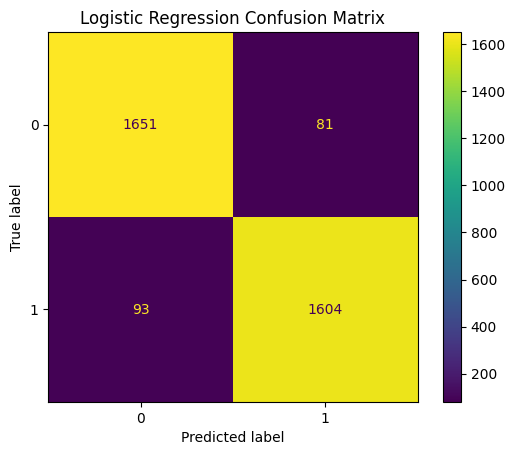

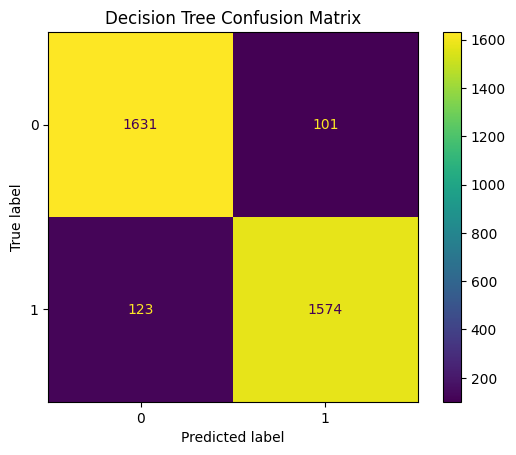

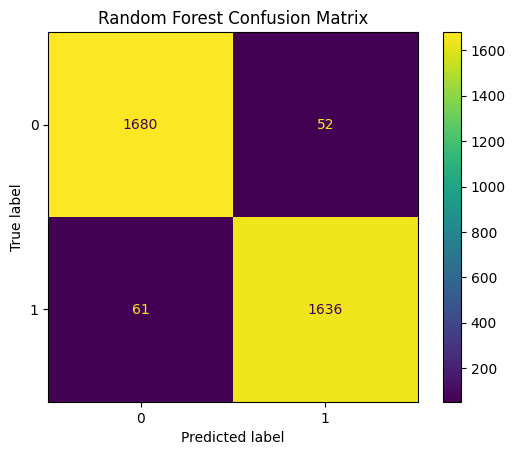

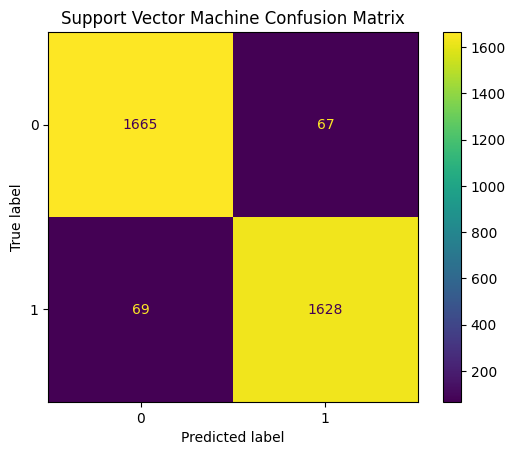

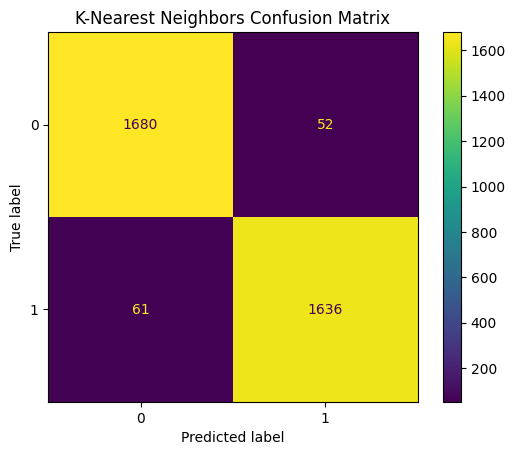

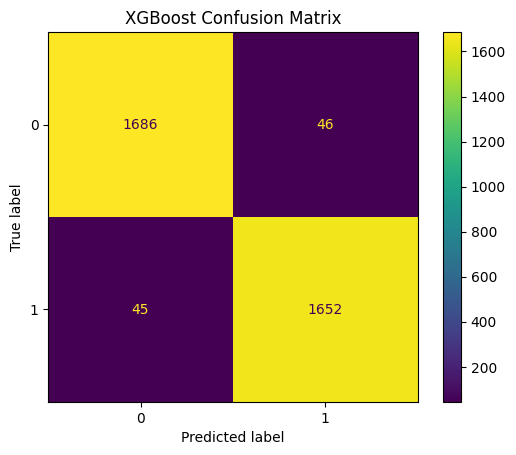

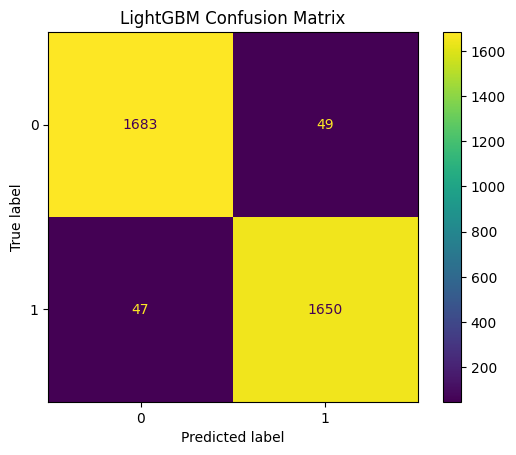

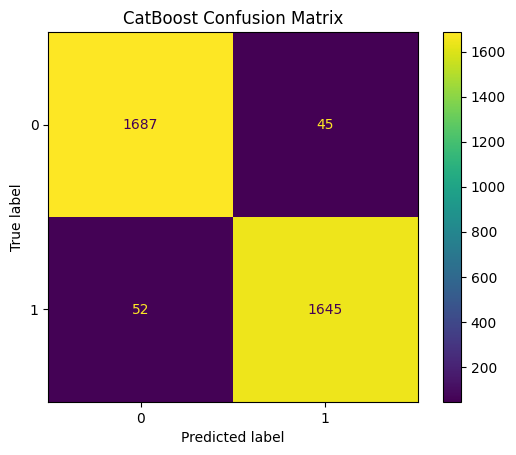

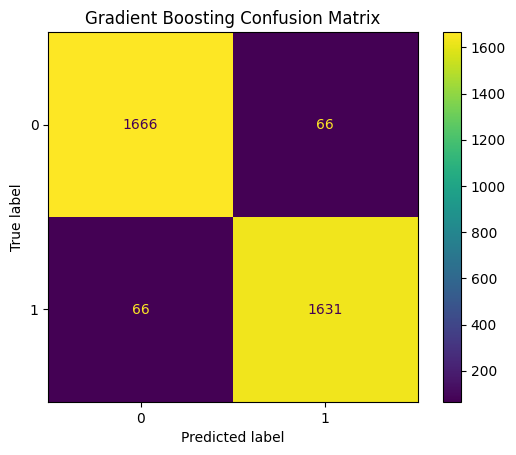

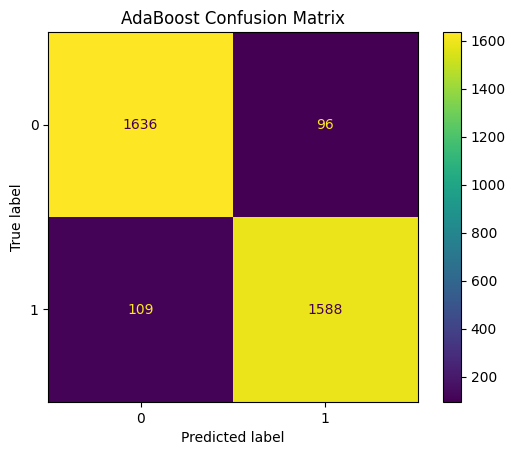

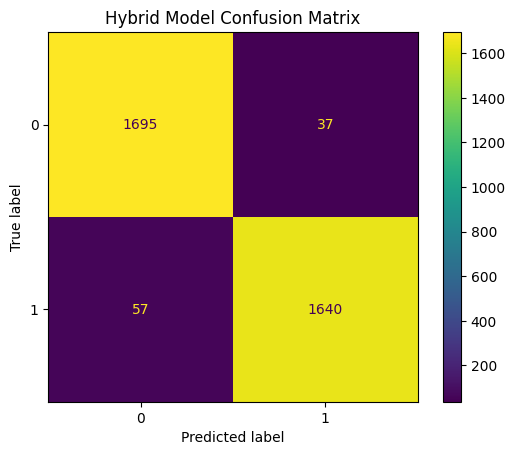

In [9]:
# Generate confusion matrices
lr_cm = confusion_matrix(y_test, lr_predictions)
dt_cm = confusion_matrix(y_test, dt_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)
svm_cm = confusion_matrix(y_test, svm_predictions)
knn_cm = confusion_matrix(y_test, rf_predictions)
xgb_cm = confusion_matrix(y_test, xgb_predictions)
lgb_cm = confusion_matrix(y_test, lgb_predictions)
cat_cm = confusion_matrix(y_test, cat_predictions)
gb_cm = confusion_matrix(y_test, gb_predictions)
ada_cm = confusion_matrix(y_test, ada_predictions)
hybrid_cm = confusion_matrix(y_test, hybrid_predictions)

# Plot confusion matrices
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=lr_model.classes_)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=dt_model.classes_)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_model.classes_)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm, display_labels=svm_model.classes_)
disp.plot()
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=knn_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=lgb_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("LightGBM Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cat_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("CatBoost Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=gb_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=ada_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=hybrid_cm, display_labels=knn_model.classes_)
disp.plot()
plt.title("Hybrid Model Confusion Matrix")
plt.show()

## ROC Curves

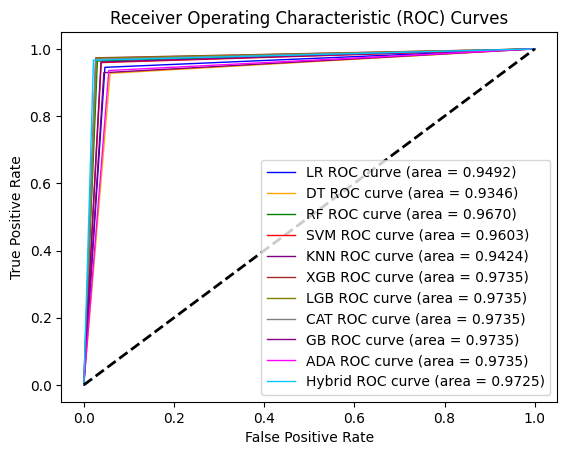

In [10]:
# Plot ROC curves. The format of the code is as follows for each model

'''
# MODEL NAME HERE

fpr, tpr, _ = roc_curve(y_test, MODEL_NAME)
roc_auc = auc(fpr, tpr) # AUC = area under the curve
plt.plot(fpr, tpr, color='black', lw=1, label=f'MODEL NAME ROC curve (area = {roc_auc:.4f})')
'''

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_predictions)
lr_roc_auc = auc(lr_fpr, lr_tpr)
plt.plot(lr_fpr, lr_tpr, color='blue', lw=1, label=f'LR ROC curve (area = {lr_roc_auc:.4f})')

# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_predictions)
dt_roc_auc = auc(dt_fpr, dt_tpr)
plt.plot(dt_fpr, dt_tpr, color='orange', lw=1, label=f'DT ROC curve (area = {dt_roc_auc:.4f})')

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_predictions)
rf_roc_auc = auc(rf_fpr, rf_tpr)
plt.plot(rf_fpr, rf_tpr, color='green', lw=1, label=f'RF ROC curve (area = {rf_roc_auc:.4f})')

# Support Vector Machine
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_predictions)
svm_roc_auc = auc(svm_fpr, svm_tpr)
plt.plot(svm_fpr, svm_tpr, color='red', lw=1, label=f'SVM ROC curve (area = {svm_roc_auc:.4f})')

# K-Nearest Neighbors
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_predictions)
knn_roc_auc = auc(knn_fpr, knn_tpr)
plt.plot(knn_fpr, knn_tpr, color='purple', lw=1, label=f'KNN ROC curve (area = {knn_roc_auc:.4f})')

# XGB
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_predictions)
xgb_roc_auc = auc(xgb_fpr, xgb_tpr)
plt.plot(xgb_fpr, xgb_tpr, color='brown', lw=1, label=f'XGB ROC curve (area = {xgb_roc_auc:.4f})')

# LGB
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_predictions)
lgb_roc_auc = auc(lgb_fpr, lgb_tpr)
plt.plot(lgb_fpr, lgb_tpr, color='olive', lw=1, label=f'LGB ROC curve (area = {xgb_roc_auc:.4f})')

# CatBoost
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_predictions)
cat_roc_auc = auc(cat_fpr, cat_tpr)
plt.plot(cat_fpr, cat_tpr, color='gray', lw=1, label=f'CAT ROC curve (area = {xgb_roc_auc:.4f})')

# Gradient Boosting
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_predictions)
gb_roc_auc = auc(gb_fpr, gb_tpr)
plt.plot(gb_fpr, gb_tpr, color='#880088', lw=1, label=f'GB ROC curve (area = {xgb_roc_auc:.4f})')

# AdaBoost
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_predictions)
ada_roc_auc = auc(ada_fpr, ada_tpr)
plt.plot(ada_fpr, ada_tpr, color='magenta', lw=1, label=f'ADA ROC curve (area = {xgb_roc_auc:.4f})')

# Hybrid Model
hybrid_fpr, hybrid_tpr, _ = roc_curve(y_test, hybrid_predictions)
hybrid_roc_auc = auc(hybrid_fpr, hybrid_tpr)
plt.plot(hybrid_fpr, hybrid_tpr, color='#00c8ff', lw=1, label=f'Hybrid ROC curve (area = {hybrid_roc_auc:.4f})')

# ----------

# Plot each ROC curve and their corresponding legend
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

## Learning Curves

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, lr_test_scores_mean, 'o-', color="blue", lw=1, label="Test score", linestyle='--')


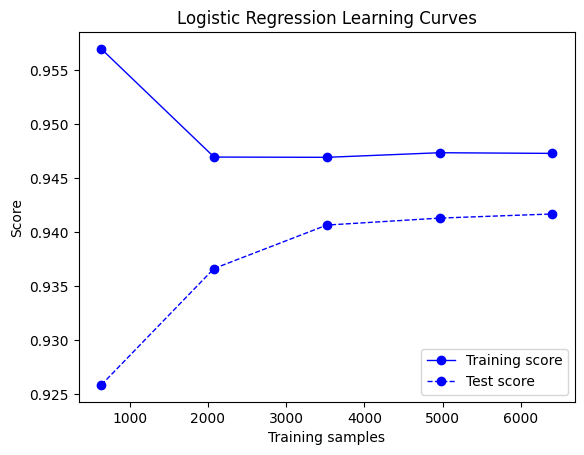

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, dt_test_scores_mean, 'o-', color="orange", lw=1, label="Test score", linestyle='--')


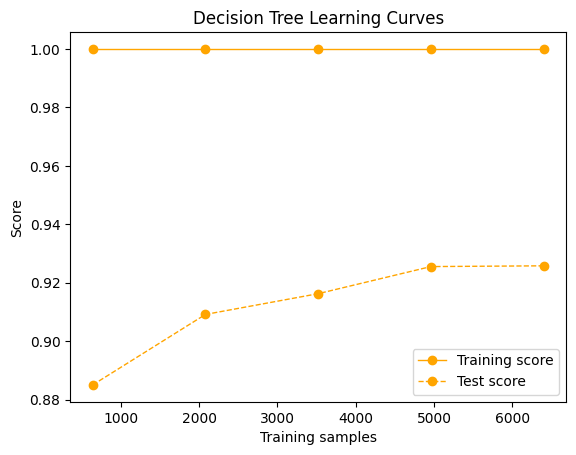

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, rf_test_scores_mean, 'o-', color="green", lw=1, label="Test score", linestyle='--')


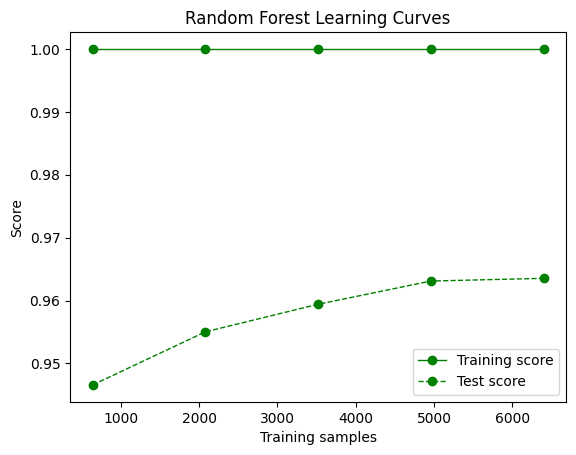

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, svm_test_scores_mean, 'o-', color="red", lw=1, label="Test score", linestyle='--')


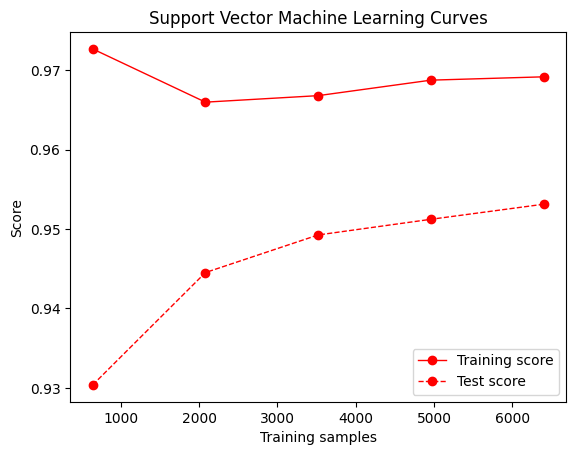

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:68: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, knn_test_scores_mean, 'o-', color="purple", lw=1, label="Test score", linestyle='--')


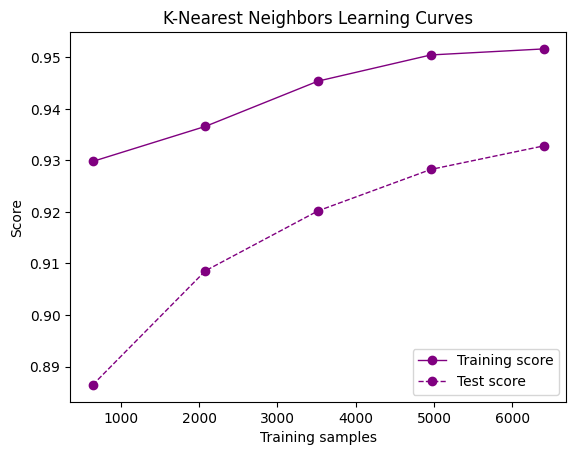

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:83: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, xgb_test_scores_mean, 'o-', color="brown", lw=1, label="Test score", linestyle='--')


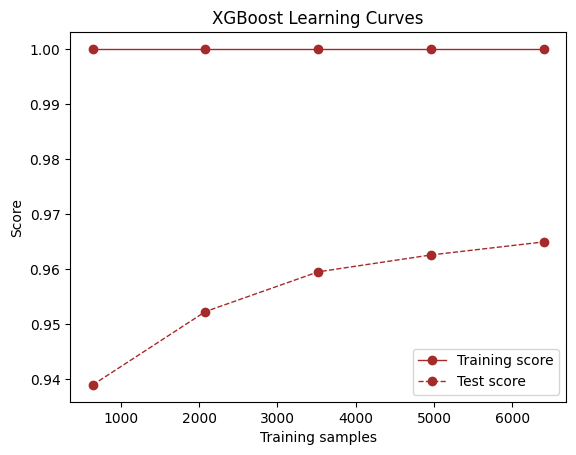

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:98: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, lgb_test_scores_mean, 'o-', color="olive", lw=1, label="Test score", linestyle='--')


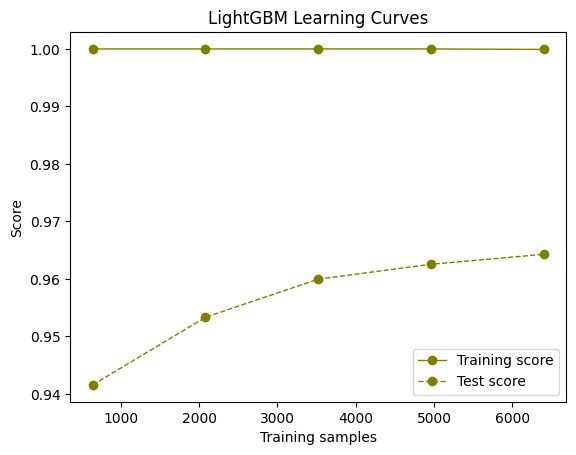

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:113: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, cat_test_scores_mean, 'o-', color="gray", lw=1, label="Test score", linestyle='--')


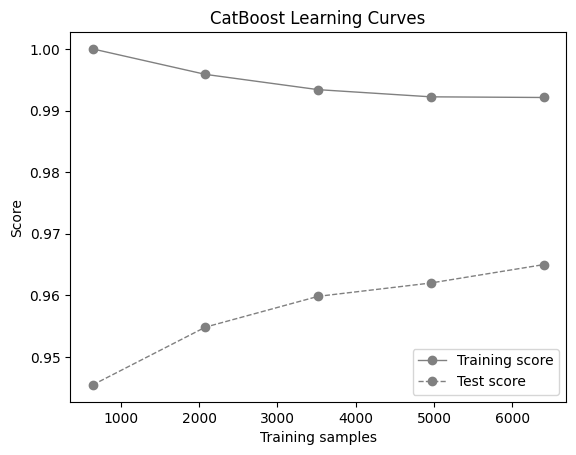

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:128: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, gb_test_scores_mean, 'o-', color="#880088", lw=1, label="Test score", linestyle='--')


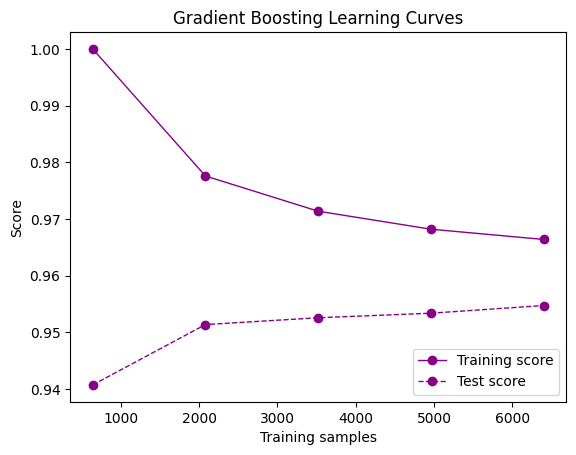

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:143: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, ada_test_scores_mean, 'o-', color="magenta", lw=1, label="Test score", linestyle='--')


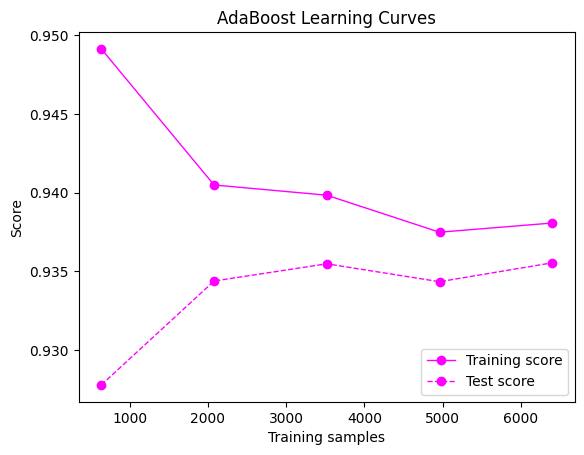

C:\Users\U68D\AppData\Local\Temp\ipykernel_12484\3056249375.py:158: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(train_sizes, hybrid_test_scores_mean, 'o-', color="#00c8ff", lw=1, label="Test score", linestyle='--')


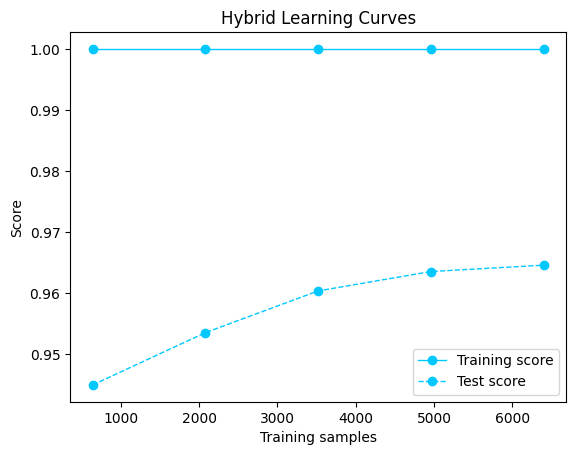

In [11]:
# Plot Learning Curves with f1-Scoring

# Logistic Regression
train_sizes, lr_train_scores, lr_test_scores = learning_curve(lr_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
lr_train_scores_mean = np.mean(lr_train_scores, axis=1)
lr_test_scores_mean = np.mean(lr_test_scores, axis=1)
plt.plot(train_sizes, lr_train_scores_mean, 'o-', color="blue", lw=1, label="Training score")
plt.plot(train_sizes, lr_test_scores_mean, 'o-', color="blue", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("Logistic Regression Learning Curves")
plt.show()
plt.close()

# Decision Tree
train_sizes, dt_train_scores, dt_test_scores = learning_curve(dt_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
dt_train_scores_mean = np.mean(dt_train_scores, axis=1)
dt_test_scores_mean = np.mean(dt_test_scores, axis=1)
plt.plot(train_sizes, dt_train_scores_mean, 'o-', color="orange", lw=1, label="Training score")
plt.plot(train_sizes, dt_test_scores_mean, 'o-', color="orange", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("Decision Tree Learning Curves")
plt.show()
plt.close()

# Random Forest
train_sizes, rf_train_scores, rf_test_scores = learning_curve(rf_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
rf_train_scores_mean = np.mean(rf_train_scores, axis=1)
rf_test_scores_mean = np.mean(rf_test_scores, axis=1)
plt.plot(train_sizes, rf_train_scores_mean, 'o-', color="green", lw=1, label="Training score")
plt.plot(train_sizes, rf_test_scores_mean, 'o-', color="green", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("Random Forest Learning Curves")
plt.show()
plt.close()

# Support Vector Machine
train_sizes, svm_train_scores, svm_test_scores = learning_curve(svm_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
svm_train_scores_mean = np.mean(svm_train_scores, axis=1)
svm_test_scores_mean = np.mean(svm_test_scores, axis=1)
plt.plot(train_sizes, svm_train_scores_mean, 'o-', color="red", lw=1, label="Training score")
plt.plot(train_sizes, svm_test_scores_mean, 'o-', color="red", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("Support Vector Machine Learning Curves")
plt.show()
plt.close()

# K-Nearest Neighbors
train_sizes, knn_train_scores, knn_test_scores = learning_curve(knn_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
knn_train_scores_mean = np.mean(knn_train_scores, axis=1)
knn_test_scores_mean = np.mean(knn_test_scores, axis=1)
plt.plot(train_sizes, knn_train_scores_mean, 'o-', color="purple", lw=1, label="Training score")
plt.plot(train_sizes, knn_test_scores_mean, 'o-', color="purple", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("K-Nearest Neighbors Learning Curves")
plt.show()
plt.close()

# XGB
train_sizes, xgb_train_scores, xgb_test_scores = learning_curve(xgb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
xgb_train_scores_mean = np.mean(xgb_train_scores, axis=1)
xgb_test_scores_mean = np.mean(xgb_test_scores, axis=1)
plt.plot(train_sizes, xgb_train_scores_mean, 'o-', color="brown", lw=1, label="Training score")
plt.plot(train_sizes, xgb_test_scores_mean, 'o-', color="brown", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("XGBoost Learning Curves")
plt.show()
plt.close()

# LGB
train_sizes, lgb_train_scores, lgb_test_scores = learning_curve(lgb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
lgb_train_scores_mean = np.mean(lgb_train_scores, axis=1)
lgb_test_scores_mean = np.mean(lgb_test_scores, axis=1)
plt.plot(train_sizes, lgb_train_scores_mean, 'o-', color="olive", lw=1, label="Training score")
plt.plot(train_sizes, lgb_test_scores_mean, 'o-', color="olive", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("LightGBM Learning Curves")
plt.show()
plt.close()

# CAT
train_sizes, cat_train_scores, cat_test_scores = learning_curve(cat_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cat_train_scores_mean = np.mean(cat_train_scores, axis=1)
cat_test_scores_mean = np.mean(cat_test_scores, axis=1)
plt.plot(train_sizes, cat_train_scores_mean, 'o-', color="gray", lw=1, label="Training score")
plt.plot(train_sizes, cat_test_scores_mean, 'o-', color="gray", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("CatBoost Learning Curves")
plt.show()
plt.close()

# Gradient Boosting
train_sizes, gb_train_scores, gb_test_scores = learning_curve(gb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
gb_train_scores_mean = np.mean(gb_train_scores, axis=1)
gb_test_scores_mean = np.mean(gb_test_scores, axis=1)
plt.plot(train_sizes, gb_train_scores_mean, 'o-', color="#880088", lw=1, label="Training score")
plt.plot(train_sizes, gb_test_scores_mean, 'o-', color="#880088", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("Gradient Boosting Learning Curves")
plt.show()
plt.close()

# AdaBoost
train_sizes, ada_train_scores, ada_test_scores = learning_curve(ada_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
ada_train_scores_mean = np.mean(ada_train_scores, axis=1)
ada_test_scores_mean = np.mean(ada_test_scores, axis=1)
plt.plot(train_sizes, ada_train_scores_mean, 'o-', color="magenta", lw=1, label="Training score")
plt.plot(train_sizes, ada_test_scores_mean, 'o-', color="magenta", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("AdaBoost Learning Curves")
plt.show()
plt.close()

# Hybrid
train_sizes, hybrid_train_scores, hybrid_test_scores = learning_curve(hybrid_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
hybrid_train_scores_mean = np.mean(hybrid_train_scores, axis=1)
hybrid_test_scores_mean = np.mean(hybrid_test_scores, axis=1)
plt.plot(train_sizes, hybrid_train_scores_mean, 'o-', color="#00c8ff", lw=1, label="Training score")
plt.plot(train_sizes, hybrid_test_scores_mean, 'o-', color="#00c8ff", lw=1, label="Test score", linestyle='--')

# Adjust legend position to the right of the graph
plt.legend(loc="lower right")
plt.xlabel("Training samples")
plt.ylabel("Score")
plt.title("Hybrid Learning Curves")
plt.show()
plt.close()

## Model Performance Evaluation

In [12]:
# Generate Classification Reports

# These reports give a more readable overview of the performance of each model
print("\n---CLASSIFICATION REPORTS---\n")
print("Logistic Regression Classification Report:\n", classification_report(y_test, lr_predictions))
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_predictions))
print("Random Forest Classification Report:\n", classification_report(y_test, rf_predictions))
print("SVM Classification Report:\n", classification_report(y_test, svm_predictions))
print("KNN Classification Report:\n", classification_report(y_test, knn_predictions))
print("XGB Classification Report:\n", classification_report(y_test, xgb_predictions))
print("LGB Classification Report:\n", classification_report(y_test, lgb_predictions))
print("CAT Classification Report:\n", classification_report(y_test, cat_predictions))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, gb_predictions))
print("AdaBoost Classification Report:\n", classification_report(y_test, ada_predictions))
print("Hybrid Classification Report:\n", classification_report(y_test, hybrid_predictions))


---CLASSIFICATION REPORTS---

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      1732
           1       0.95      0.95      0.95      1697

    accuracy                           0.95      3429
   macro avg       0.95      0.95      0.95      3429
weighted avg       0.95      0.95      0.95      3429

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      1732
           1       0.94      0.93      0.93      1697

    accuracy                           0.93      3429
   macro avg       0.93      0.93      0.93      3429
weighted avg       0.93      0.93      0.93      3429

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      1732
           1       0.97      0.96      0.97      1697

    accuracy                   

In [13]:
# Print accuracy scores
print("---ACCURACY SCORES---\n")

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("SVM Accuracy:", accuracy_score(y_test, svm_predictions))
print("KNN Accuracy:", accuracy_score(y_test, knn_predictions))
print("XGB Accuracy:", accuracy_score(y_test, xgb_predictions))
print("LGB Accuracy:", accuracy_score(y_test, lgb_predictions))
print("CAT Accuracy:", accuracy_score(y_test, cat_predictions))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_predictions))
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_predictions))
print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_predictions))

# Calculate precision, recall, F1-score, and support for each model
lr_precision, lr_recall, lr_fscore, _ = precision_recall_fscore_support(y_test, lr_predictions)
dt_precision, dt_recall, dt_fscore, _ = precision_recall_fscore_support(y_test, dt_predictions)
rf_precision, rf_recall, rf_fscore, _ = precision_recall_fscore_support(y_test, rf_predictions)
svm_precision, svm_recall, svm_fscore, _ = precision_recall_fscore_support(y_test, svm_predictions)
knn_precision, knn_recall, knn_fscore, _ = precision_recall_fscore_support(y_test, knn_predictions)
xgb_precision, xgb_recall, xgb_fscore, _ = precision_recall_fscore_support(y_test, xgb_predictions)
lgb_precision, lgb_recall, lgb_fscore, _ = precision_recall_fscore_support(y_test, lgb_predictions)
cat_precision, cat_recall, cat_fscore, _ = precision_recall_fscore_support(y_test, cat_predictions)
gb_precision, gb_recall, gb_fscore, _ = precision_recall_fscore_support(y_test, gb_predictions)
ada_precision, ada_recall, ada_fscore, _ = precision_recall_fscore_support(y_test, ada_predictions)
hybrid_precision, hybrid_recall, hybrid_fscore, _ = precision_recall_fscore_support(y_test, hybrid_predictions)

# Display all scores below, formatted such that 0 and 1 are each considered TPs respectively.

print("\n---PRECISION SCORES---\n")

print("Logistic Regression Precision:\n\t0:", lr_precision[0], "\n\t1:", lr_precision[1])
print("Decision Tree Precision:\n\t0:", dt_precision[0], "\n\t1:", dt_precision[1])
print("Random Forest Precision:\n\t0:", rf_precision[0], "\n\t1:", rf_precision[1])
print("SVM Precision:\n\t0:", svm_precision[0], "\n\t1:", svm_precision[1])
print("KNN Precision:\n\t0:", knn_precision[0], "\n\t1:", knn_precision[1])
print("XGB Precision:\n\t0:", xgb_precision[0], "\n\t1:", xgb_precision[1])
print("LGB Precision:\n\t0:", lgb_precision[0], "\n\t1:", lgb_precision[1])
print("CAT Precision:\n\t0:", cat_precision[0], "\n\t1:", cat_precision[1])
print("Gradient Boosting Precision:\n\t0:", gb_precision[0], "\n\t1:", gb_precision[1])
print("AdaBoost Precision:\n\t0:", ada_precision[0], "\n\t1:", ada_precision[1])
print("Hybrid Precision:\n\t0:", hybrid_precision[0], "\n\t1:", hybrid_precision[1])

print("\n---RECALL SCORES---\n")

print("Logistic Regression Recall:\n\t0:", lr_recall[0], "\n\t1:", lr_recall[1])
print("Decision Tree Recall:\n\t0:", dt_recall[0], "\n\t1:", dt_recall[1])
print("Random Forest Recall:\n\t0:", rf_recall[0], "\n\t1:", rf_recall[1])
print("SVM Recall:\n\t0:", svm_recall[0], "\n\t1:", svm_recall[1])
print("KNN Recall:\n\t0:", knn_recall[0], "\n\t1:", knn_recall[1])
print("XGB Recall:\n\t0:", xgb_recall[0], "\n\t1:", xgb_recall[1])
print("LGB Recall:\n\t0:", lgb_recall[0], "\n\t1:", lgb_recall[1])
print("CAT Recall:\n\t0:", cat_recall[0], "\n\t1:", cat_recall[1])
print("Gradient Boosting Recall:\n\t0:", gb_recall[0], "\n\t1:", gb_recall[1])
print("AdaBoost Recall:\n\t0:", ada_recall[0], "\n\t1:", ada_recall[1])
print("Hybrid Recall:\n\t0:", hybrid_recall[0], "\n\t1:", hybrid_recall[1])

print("\n---F1-SCORES---\n")

print("Logistic Regression F1-Score:\n\t0:", lr_fscore[0], "\n\t1:", lr_fscore[1])
print("Decision Tree F1-Score:\n\t0:", dt_fscore[0], "\n\t1:", dt_fscore[1])
print("Random Forest F1-Score:\n\t0:", rf_fscore[0], "\n\t1:", rf_fscore[1])
print("SVM F1-Score:\n\t0:", svm_fscore[0], "\n\t1:", svm_fscore[1])
print("KNN F1-Score:\n\t0:", knn_fscore[0], "\n\t1:", knn_fscore[1])
print("XGB F1-Score:\n\t0:", xgb_fscore[0], "\n\t1:", xgb_fscore[1])
print("LGB F1-Score:\n\t0:", lgb_fscore[0], "\n\t1:", lgb_fscore[1])
print("CAT F1-Score:\n\t0:", cat_fscore[0], "\n\t1:", cat_fscore[1])
print("Gradient Boosting F1-Score:\n\t0:", gb_fscore[0], "\n\t1:", gb_fscore[1])
print("AdaBoost F1-Score:\n\t0:", ada_fscore[0], "\n\t1:", ada_fscore[1])
print("Hybrid F1-Score:\n\t0:", hybrid_fscore[0], "\n\t1:", hybrid_fscore[1])

---ACCURACY SCORES---

Logistic Regression Accuracy: 0.9492563429571304
Decision Tree Accuracy: 0.9346748323126276
Random Forest Accuracy: 0.9670457859434237
SVM Accuracy: 0.9603382910469525
KNN Accuracy: 0.9425488480606591
XGB Accuracy: 0.973461650627005
LGB Accuracy: 0.9720034995625547
CAT Accuracy: 0.9717118693496646
Gradient Boosting Accuracy: 0.9615048118985127
AdaBoost Accuracy: 0.9402158063575387
Hybrid Accuracy: 0.9725867599883348

---PRECISION SCORES---

Logistic Regression Precision:
	0: 0.9466743119266054 
	1: 0.9519287833827893
Decision Tree Precision:
	0: 0.9298745724059293 
	1: 0.9397014925373134
Random Forest Precision:
	0: 0.9649626651349799 
	1: 0.9691943127962085
SVM Precision:
	0: 0.9602076124567474 
	1: 0.96047197640118
KNN Precision:
	0: 0.9323943661971831 
	1: 0.9534461910519951
XGB Precision:
	0: 0.9740034662045061 
	1: 0.9729093050647821
LGB Precision:
	0: 0.9728323699421966 
	1: 0.9711595055915244
CAT Precision:
	0: 0.9700977573317999 
	1: 0.9733727810650887
Gr